# Getting started with Extension Tracker's data

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/WebIterate-Dev/extension-tracker-notebooks/blob/main/01-getting-started.ipynb) [![Open in Kaggle](https://kaggle.com/static/images/open-in-kaggle.svg)](https://kaggle.com/kernels/welcome?src=https://github.com/WebIterate-Dev/extension-tracker-notebooks/blob/main/01-getting-started.ipynb)

[Extension Tracker](https://extensiontracker.com) keeps a public record of the extensions in the
Chrome Web Store: their users, ratings, versions, permissions and changes over time. Every Sunday it
publishes the data as a set of files at `data.extensiontracker.com`.

This notebook reads one set, shows what's in it, and answers a few first questions: which extensions
have the most users, how extensions spread across categories, how they're rated, and when they were
first published.

Every column is explained in the set's `SCHEMA.md`, and how the data is collected in the
[methodology](https://extensiontracker.com/methodology).

## Setup

Colab and Kaggle already have pandas, pyarrow and matplotlib, so there's nothing to install. On
Kaggle, the notebook needs internet access to read the files: if a cell can't connect, turn on
Internet in the notebook's settings, which Kaggle allows once your account has a verified phone
number.

In [1]:
import json
import urllib.request

import matplotlib.pyplot as plt
import pandas as pd


# The set of files to read. Sets come out every Sunday and never change, so a
# notebook that reads one dated set gives the same results every time.
# https://data.extensiontracker.com/index.json lists every set.
SET = "2026-09-29"
BASE = f"https://data.extensiontracker.com/{SET}/"


def read(name, **options):
    """Read one of the set's Parquet files, such as "extensions"."""
    return pd.read_parquet(f"{BASE}{name}-{SET}.parquet", dtype_backend="numpy_nullable", **options)


DATA = "#0b6f85"  # the color of Extension Tracker's charts
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
pd.options.display.max_colwidth = 60

To read the newest set instead, set `SET` from `latest.json`:

```python
with urllib.request.urlopen("https://data.extensiontracker.com/latest.json") as response:
    SET = json.load(response)["date"]
BASE = f"https://data.extensiontracker.com/{SET}/"
```

## What's in a set

Each set has a manifest that lists its files, with their size and number of rows.

In [2]:
with urllib.request.urlopen(BASE + "manifest.json") as response:
    manifest = json.load(response)

files = pd.DataFrame(manifest["files"])
files["MB"] = (files["bytes"] / 1e6).round(1)
files["rows"] = files["rows"].astype("Int64")
files[["name", "MB", "rows"]]

,name,MB,rows
0,extensions-2026-09-29.parquet,82.7,265478
1,extensions-2026-09-29.csv.gz,95.2,265478
2,history-2026-09-29.parquet,5.4,276347
3,changes-2026-09-29.parquet,0.5,14735
4,other-items-2026-09-29.csv.gz,3.9,103210
5,coverage-2026-09-29.json,0.0,<NA>
6,SCHEMA.md,0.0,<NA>


## The extensions file

One row per extension, including extensions that have left the store. The file is large, so we read
only the columns we need.

In [3]:
columns = ["id", "name", "status", "category", "users", "rating", "rating_count", "published_at"]
extensions = read("extensions", columns=columns)
print(f"{len(extensions):,} extensions")
extensions.head()

265,478 extensions


,id,name,status,category,users,rating,rating_count,published_at
0,bapflcjdlpflhabjngomnoegmkafjmoi,Link Saver,live,productivity/workflow,15,<NA>,<NA>,2023-09-18 07:21:03+00:00
1,afmakljhfhpnanccmajdgoplobdopcfp,Epstein Records Indicator,live,productivity/workflow,11,<NA>,<NA>,2026-03-10 12:49:17+00:00
2,bkmhonjngmdoegjahjddlionblnimbbg,BroDraw,live,productivity/workflow,<NA>,<NA>,<NA>,2026-05-10 11:11:13+00:00
3,nhangkbdjnopgkgklfdkpfgmendlckpe,Archify,live,productivity/developer,281,5.0,5,2026-06-30 11:31:41+00:00
4,ljjiijcjhomchjklpnmhfbdohjpbkiig,Clean ChatGPT UTM Links,live,productivity/tools,148,<NA>,<NA>,2026-02-20 04:24:52+00:00


Each extension has a status. Most are live. The others have left the store, or can't be seen by
Extension Tracker's crawler right now; the [methodology](https://extensiontracker.com/methodology)
explains each status.

In [4]:
extensions["status"].value_counts().to_frame("extensions")

,extensions
status,
live,265464
hidden,6
removed,4
missing,4


From here on, we look at live extensions only.

In [5]:
live = extensions[extensions["status"] == "live"].copy()
print(f"{len(live):,} live extensions")

265,464 live extensions


## Users

The store shows a user count on most listings, but not on many new ones. Most extensions have few
users, and a small number have millions.

In [6]:
bands = pd.cut(
    live["users"],
    bins=[0, 100, 1_000, 10_000, 100_000, 1_000_000, float("inf")],
    labels=["Under 100", "100 to 999", "1,000 to 9,999", "10,000 to 99,999", "100,000 to 999,999",
            "1,000,000 or more"],
    right=False,
)
by_users = bands.value_counts(sort=False).to_frame("extensions")
by_users.loc["No user count"] = live["users"].isna().sum()
by_users["share (%)"] = (by_users["extensions"] / len(live) * 100).round(1)
by_users

,extensions,share (%)
users,,
Under 100,189511,71.4
100 to 999,41522,15.6
"1,000 to 9,999",16653,6.3
"10,000 to 99,999",6050,2.3
"100,000 to 999,999",1433,0.5
"1,000,000 or more",314,0.1
No user count,9981,3.8


The 20 live extensions with the most users, with a link to each one's page:

In [7]:
top = live.sort_values("users", ascending=False).head(20)
top = top.assign(page="https://extensiontracker.com/extension/" + top["id"])
top[["name", "users", "rating", "category", "page"]].reset_index(drop=True)

,name,users,rating,category,page
0,"Adobe Acrobat: PDF edit, convert, sign tools",336000000,4.402,productivity/workflow,https://extensiontracker.com/extension/efaidnbmnnnibpcaj...
1,迅雷下载支持,79000000,2.845,productivity/tools,https://extensiontracker.com/extension/ncennffkjdiamlpmc...
2,AdBlock — block ads across the web,64000000,4.473,productivity/workflow,https://extensiontracker.com/extension/gighmmpiobklfepjo...
3,Chrome Remote Desktop,40000000,3.144,productivity/workflow,https://extensiontracker.com/extension/inomeogfingihgjfj...
4,Adblock Plus - free ad blocker,40000000,4.392,productivity/workflow,https://extensiontracker.com/extension/cfhdojbkjhnklbpkd...
5,Grammarly: AI Writing Assistant and Grammar Checker App,40000000,4.494,productivity/communication,https://extensiontracker.com/extension/kbfnbcaeplbcioakk...
6,Google Translate,38000000,4.234,productivity/education,https://extensiontracker.com/extension/aapbdbdomjkkjkaon...
7,Microsoft Single Sign On,36000000,2.185,productivity/workflow,https://extensiontracker.com/extension/ppnbnpeolgkicgegk...
8,Cisco Webex Extension,22000000,2.338,lifestyle/social,https://extensiontracker.com/extension/jlhmfgmfgeifomene...
9,uBlock Origin Lite,21000000,4.502,make_chrome_yours/privacy,https://extensiontracker.com/extension/ddkjiahejlhfcafbd...


## Categories

The store files each extension under one category. Here's how many live extensions each category
has, and how many users they add up to. Someone who uses several extensions counts once for each.

In [8]:
categories = live.groupby("category").agg(extensions=("id", "size"), users=("users", "sum"))
categories.sort_values("extensions", ascending=False)

,extensions,users
category,,
productivity/tools,103857,352715511
productivity/workflow,44586,1051602955
productivity/developer,27694,118311911
productivity/education,11093,104325612
make_chrome_yours/functionality,10928,27789530
lifestyle/fun,9255,37674114
lifestyle/shopping,8457,63875692
make_chrome_yours/accessibility,7996,142273494
lifestyle/social,7025,69370191


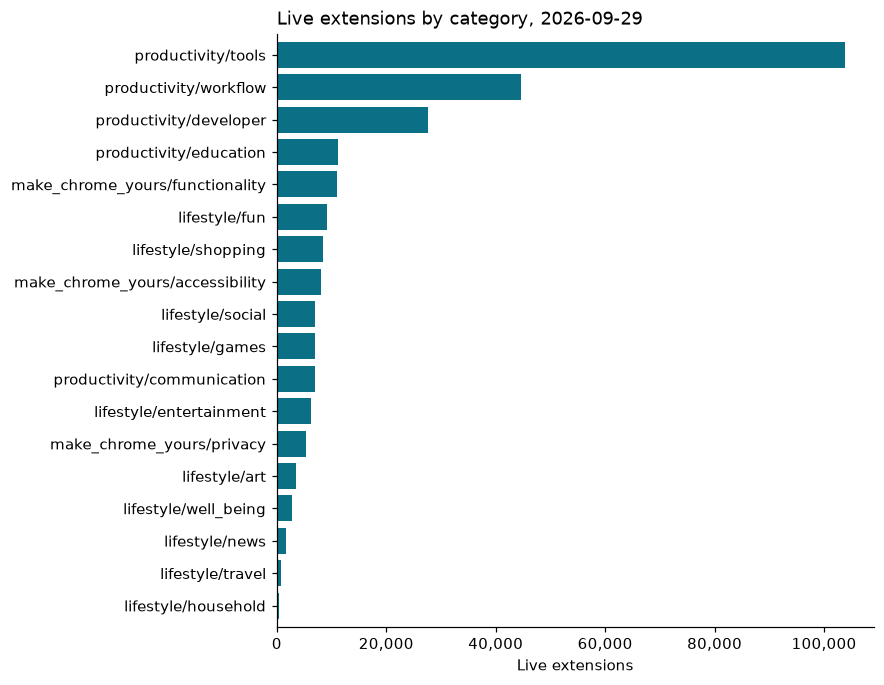

In [9]:
ax = categories["extensions"].sort_values().plot.barh(figsize=(7, 7), color=DATA, width=0.8)
ax.set_title(f"Live extensions by category, {SET}", loc="left")
ax.set_xlabel("Live extensions")
ax.set_ylabel("")
ax.xaxis.set_major_formatter("{x:,.0f}")
plt.show()

## Ratings

An average rating says little when it comes from a handful of ratings, so this looks at extensions
with at least 50.

6,781 live extensions have 50 or more ratings


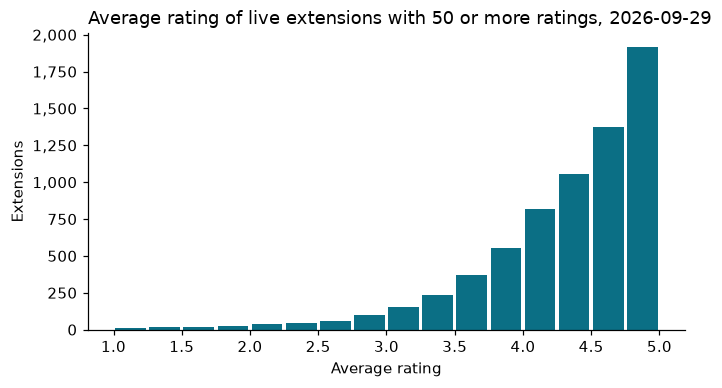

In [10]:
rated = live[live["rating_count"] >= 50]
print(f"{len(rated):,} live extensions have 50 or more ratings")

ax = rated["rating"].astype(float).plot.hist(
    bins=[1 + step * 0.25 for step in range(17)], figsize=(7, 3.5), color=DATA, rwidth=0.9
)
ax.set_title(f"Average rating of live extensions with 50 or more ratings, {SET}", loc="left")
ax.set_xlabel("Average rating")
ax.set_ylabel("Extensions")
ax.yaxis.set_major_formatter("{x:,.0f}")
plt.show()

Filters combine. For example, the live extensions with the most users whose average rating is
below 2, from at least 50 ratings:

In [11]:
low = live[(live["rating"] < 2) & (live["rating_count"] >= 50)]
low.sort_values("users", ascending=False).head(10)[["name", "users", "rating", "rating_count", "category"]]

,name,users,rating,rating_count,category
155105,ClassLink OneClick Extension,18000000,1.682,619,productivity/workflow
63299,touchenex 확장,8000000,1.327,6323,productivity/developer
223914,Lightspeed Insight Agent,7000000,1.192,224,productivity/workflow
245333,네이버 동영상 플러그인,5000000,1.411,3651,make_chrome_yours/accessibility
216469,LearnPlatform for Students,5000000,1.25,88,productivity/workflow
148761,Госплагин,5000000,1.422,358,make_chrome_yours/privacy
114720,夸克网盘-网页嗅探,3000000,1.714,84,productivity/workflow
2833,Адаптер Рутокен Коннект,2000000,1.564,188,productivity/workflow
254451,Pix Companion,2000000,1.439,214,productivity/education
29264,Snow Web Application Metering,2000000,1.329,155,productivity/workflow


## When extensions were first published

Live extensions by the year they were first published in the store. The latest year runs only to
the set's date.

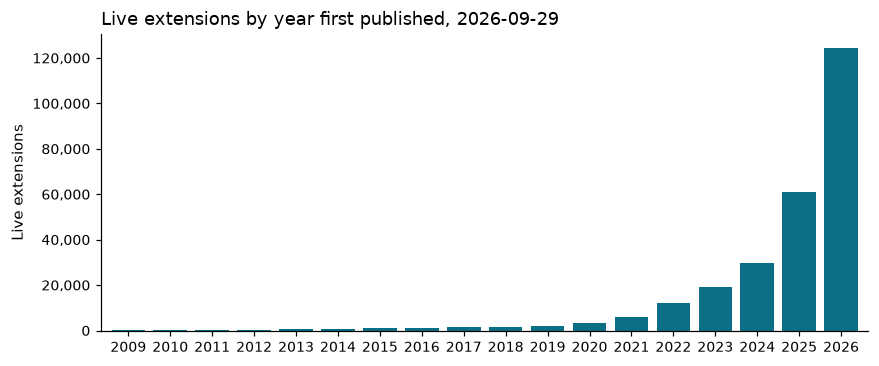

In [12]:
years = live["published_at"].dt.year.dropna().astype(int).value_counts().sort_index()

ax = years.plot.bar(figsize=(9, 3.5), color=DATA, width=0.8, rot=0, fontsize=9)
ax.set_title(f"Live extensions by year first published, {SET}", loc="left")
ax.set_xlabel("")
ax.set_ylabel("Live extensions")
ax.yaxis.set_major_formatter("{x:,.0f}")
plt.show()

## Credit

The data is under [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/): if you use it, credit
Extension Tracker and link to https://extensiontracker.com. Names, summaries and other text written
by developers belong to them. The data is collected automatically, so check an important fact against
the extension's store listing before relying on it.

The other notebooks look at [permissions](02-permissions.ipynb) and at
[changes and removals](03-changes-and-removals.ipynb).